In [25]:
import relativistic_model_track as rmt # import our module
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

In [26]:
# Simple tracker geometry: 7 equally spaced layers over 1 m
z_layers = np.linspace(0.1, 0.9, 7)  # [m] (avoid z=0 so we don't sit right at origin)
print("Tracker layers at z =", z_layers)

Tracker layers at z = [0.1        0.23333333 0.36666667 0.5        0.63333333 0.76666667
 0.9       ]


In [ ]:
def intersect_track_with_layers(t, r, z_layers, direction="forward"):
    """
    Find intersections of a track r(t) with tracker planes z = const.

    Parameters
    ----------
    t : (N,) array
        Time samples.
    r : (N, 3) array
        Positions.
    z_layers : (L,) array
        Layer z positions [m].
    direction : {"forward", "both"}
        If "forward", require that the track is moving in +z on average (typical AMS case).

    Returns
    -------
    hits : list of dicts
        Each dict has keys: 'layer_index', 'z_layer', 'x', 'y', 'z', 't'.
    """
    z = r[:, 2]
    hits = []

    for i_layer, zL in enumerate(z_layers):
        for i in range(len(z) - 1):
            z1, z2 = z[i], z[i + 1]

            # Check if segment crosses z = zL
            if (z1 - zL) * (z2 - zL) <= 0 and (z2 != z1): #if layer is between z1 and z2
                # Optional direction check (rough)
                if direction == "forward" and (z2 - z1) <= 0:
                    continue

                # Trilinear interpolation in parameter alpha
                alpha = (zL - z1) / (z2 - z1)
                x1, y1, z1 = r[i]
                x2, y2, z2 = r[i + 1]

                x_hit = x1 + alpha * (x2 - x1)
                y_hit = y1 + alpha * (y2 - y1)
                z_hit = zL
                t_hit = t[i] + alpha * (t[i + 1] - t[i])

                hits.append(
                    dict(
                        layer_index=i_layer,
                        z_layer=zL,
                        x=x_hit,
                        y=y_hit,
                        z=z_hit,
                        t=t_hit,
                    )
                )
                break  # move to next layer once we found the first crossing

    return hits


In [28]:
# --- Constants ---
e_charge = 1.602176634e-19  # C
proton_mass = 1.67262192369e-27  # kg

c = 3.0e8  # m/s
B0 = np.array([0.0, 0.0, 0.15])  # T

# Proton mass in GeV/c^2
m_p_GeV = 0.9382720813

R_GV = 10.0  # Rigidity in GV

# Proton: Z = +1
t_p, r_p, v_p, gamma_p = rmt.simulate_relativistic_track(
    Z=+1,
    mass_GeV=m_p_GeV,
    mass_kg=proton_mass,
    R_GV=R_GV,
    B_vec=B0,
    n_periods=2.0,
    steps_per_period=200
)

hits_p = intersect_track_with_layers(t_p, r_p, z_layers)

Z = 1, R = 10.000 GV
p = 10.000 GeV/c, gamma = 10.705, beta = 0.9956, v = 2.987e+08 m/s
Relativistic cyclotron period T_c = 4.681e-06 s


In [29]:
def add_hit_noise(hits, sigma_xy=50e-6, rng=None):
    """
    Add Gaussian noise in x,y to a list of hit dicts.

    Parameters
    ----------
    hits : list of dicts
        Output of intersect_track_with_layers.
    sigma_xy : float
        Standard deviation of position noise in x,y [m].
    rng : np.random.Generator or None
        Random generator.

    Returns
    -------
    noisy_hits : list of dicts
        Same structure as input but with x_meas, y_meas fields added.
    """
    if rng is None:
        rng = np.random.default_rng()

    noisy_hits = []
    for h in hits:
        dx = rng.normal(0.0, sigma_xy)
        dy = rng.normal(0.0, sigma_xy)

        h2 = h.copy()
        h2["x_true"] = h["x"]
        h2["y_true"] = h["y"]
        h2["x_meas"] = h["x"] + dx
        h2["y_meas"] = h["y"] + dy
        noisy_hits.append(h2)

    return noisy_hits


noisy_hits_p = add_hit_noise(hits_p, sigma_xy=50e-6)
noisy_hits_p[:3]  # peek at first 3 hits

[{'layer_index': 0,
  'z_layer': np.float64(0.1),
  'x': np.float64(0.0054400558127328654),
  'y': np.float64(0.1731196285600057),
  'z': np.float64(0.1),
  't': np.float64(6.695947514016619e-10),
  'x_true': np.float64(0.0054400558127328654),
  'y_true': np.float64(0.1731196285600057),
  'x_meas': np.float64(0.005470308779900441),
  'y_meas': np.float64(0.1731111247927593)},
 {'layer_index': 1,
  'z_layer': np.float64(0.23333333333333334),
  'x': np.float64(0.01269346356304335),
  'y': np.float64(0.40394579997334656),
  'z': np.float64(0.23333333333333334),
  't': np.float64(1.5623877532705443e-09),
  'x_true': np.float64(0.01269346356304335),
  'y_true': np.float64(0.40394579997334656),
  'x_meas': np.float64(0.012748394876486591),
  'y_meas': np.float64(0.4040364392641907)},
 {'layer_index': 2,
  'z_layer': np.float64(0.3666666666666667),
  'x': np.float64(0.019946871313353837),
  'y': np.float64(0.6347719713866875),
  'z': np.float64(0.3666666666666667),
  't': np.float64(2.4551807

In [30]:
def hits_to_dataframe(noisy_hits, event_id, Z, R_GV, particle_label="p"):
    """
    Convert list of noisy hits to a pandas DataFrame with metadata.
    """
    rows = []
    for h in noisy_hits:
        rows.append(
            dict(
                event_id=event_id,
                particle=particle_label,
                Z=Z,
                R_GV=R_GV,
                layer_index=h["layer_index"],
                z_layer=h["z_layer"],
                x_true=h["x_true"],
                y_true=h["y_true"],
                x_meas=h["x_meas"],
                y_meas=h["y_meas"],
                t=h["t"],
            )
        )
    return pd.DataFrame(rows)

df_p = hits_to_dataframe(noisy_hits_p, event_id=0, Z=+1, R_GV=R_GV, particle_label="p")
df_p.to_csv("../../data/week1_single_proton_hits.csv", index=False)

In [31]:
df_p.info()
df_p.head(7) #every hit is shown here

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   event_id     7 non-null      int64  
 1   particle     7 non-null      object 
 2   Z            7 non-null      int64  
 3   R_GV         7 non-null      float64
 4   layer_index  7 non-null      int64  
 5   z_layer      7 non-null      float64
 6   x_true       7 non-null      float64
 7   y_true       7 non-null      float64
 8   x_meas       7 non-null      float64
 9   y_meas       7 non-null      float64
 10  t            7 non-null      float64
dtypes: float64(7), int64(3), object(1)
memory usage: 748.0+ bytes


,event_id,particle,Z,R_GV,layer_index,z_layer,x_true,y_true,x_meas,y_meas,t
0,0,p,1,10.0,0,0.100000,0.005440,0.173120,0.005470,0.173111,6.695948e-10
1,0,p,1,10.0,1,0.233333,0.012693,0.403946,0.012748,0.404036,1.562388e-09
2,0,p,1,10.0,2,0.366667,0.019947,0.634772,0.020006,0.634843,2.455181e-09
3,0,p,1,10.0,3,0.500000,0.027200,0.865598,0.027160,0.865624,3.347974e-09
4,0,p,1,10.0,4,0.633333,0.034454,1.096424,0.034411,1.096544,4.240767e-09
5,0,p,1,10.0,5,0.766667,0.041707,1.327250,0.041810,1.327309,5.133560e-09
6,0,p,1,10.0,6,0.900000,0.048961,1.558077,0.049016,1.558008,6.026353e-09


In [32]:
#--- Simulate multiple events ---

def generate_proton_event(event_id, R_GV, pitch_angle_deg, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    # simulate track
    t, r, v, gamma = rmt.simulate_relativistic_track(
        Z=+1,
        mass_GeV=m_p_GeV,
        mass_kg=proton_mass,
        R_GV=R_GV,
        pitch_angle_deg=pitch_angle_deg,
        B_vec=B0,
        n_periods=2.0,
        steps_per_period=300,
    )

    hits = intersect_track_with_layers(t, r, z_layers)
    noisy_hits = add_hit_noise(hits, sigma_xy=50e-6, rng=rng)
    df = hits_to_dataframe(noisy_hits, event_id=event_id, Z=+1, R_GV=R_GV, particle_label="p")
    df["pitch_deg"] = pitch_angle_deg
    return df, r  # returning r so we can, if we want, compare true radius as well

In [ ]:
rng = np.random.default_rng(42) #seed for reproducibility

events = []
n_events = 50

for ev in range(n_events):
    R_GV_sample = rng.uniform(5.0, 20.0)        # 5–20 GV
    pitch_sample = rng.uniform(30.0, 80.0)      # 30–80 deg

    df_ev, _ = generate_proton_event(ev, R_GV_sample, pitch_sample, rng=rng)
    events.append(df_ev)

df_all = pd.concat(events, ignore_index=True)
df_all.to_csv("../../data/week1_multiple_proton_hits.csv", index=False)
df_all.head()

Z = 1, R = 16.609 GV
p = 16.609 GeV/c, gamma = 17.730, beta = 0.9984, v = 2.995e+08 m/s
Relativistic cyclotron period T_c = 7.753e-06 s
Z = 1, R = 13.319 GV
p = 13.319 GeV/c, gamma = 14.230, beta = 0.9975, v = 2.993e+08 m/s
Relativistic cyclotron period T_c = 6.223e-06 s
Z = 1, R = 9.887 GV
p = 9.887 GeV/c, gamma = 10.585, beta = 0.9955, v = 2.987e+08 m/s
Relativistic cyclotron period T_c = 4.629e-06 s
Z = 1, R = 7.999 GV
p = 7.999 GeV/c, gamma = 8.583, beta = 0.9932, v = 2.980e+08 m/s
Relativistic cyclotron period T_c = 3.753e-06 s
Z = 1, R = 13.388 GV
p = 13.388 GeV/c, gamma = 14.304, beta = 0.9976, v = 2.993e+08 m/s
Relativistic cyclotron period T_c = 6.255e-06 s
Z = 1, R = 17.210 GV
p = 17.210 GeV/c, gamma = 18.370, beta = 0.9985, v = 2.996e+08 m/s
Relativistic cyclotron period T_c = 8.033e-06 s
Z = 1, R = 6.770 GV
p = 6.770 GeV/c, gamma = 7.284, beta = 0.9905, v = 2.972e+08 m/s
Relativistic cyclotron period T_c = 3.185e-06 s
Z = 1, R = 7.652 GV
p = 7.652 GeV/c, gamma = 8.216, beta

,event_id,particle,Z,R_GV,layer_index,z_layer,x_true,y_true,x_meas,y_meas,t,pitch_deg
0,0,p,1,16.609341,0,0.100000,0.002675,0.127708,0.002713,0.127755,5.416081e-10,51.943922
1,0,p,1,16.609341,1,0.233333,0.006242,0.297986,0.006144,0.297921,1.263752e-09,51.943922
2,0,p,1,16.609341,2,0.366667,0.009808,0.468264,0.009815,0.468248,1.985896e-09,51.943922
3,0,p,1,16.609341,3,0.500000,0.013375,0.638541,0.013374,0.638499,2.708040e-09,51.943922
4,0,p,1,16.609341,4,0.633333,0.016942,0.808819,0.016986,0.808858,3.430184e-09,51.943922


In [34]:
def estimate_radius_from_hits(df_hits, B_vec=B0):
    """
    Given hits of a single event, fit circle in x,y using measured positions.
    Returns fitted radius.
    """
    x_meas = df_hits["x_meas"].values
    y_meas = df_hits["y_meas"].values
    xc, yc, R_fit = rmt.fit_circle_least_squares(x_meas, y_meas)
    return R_fit


records = []
for ev_id, df_ev in df_all.groupby("event_id"):
    R_GV = df_ev["R_GV"].iloc[0]
    pitch_deg = df_ev["pitch_deg"].iloc[0]

    R_th = rmt.theoretical_radius(R_GV, pitch_deg, Z=+1, mass_GeV=m_p_GeV, B_vec=B0)
    R_fit_ev = estimate_radius_from_hits(df_ev, B_vec=B0)

    records.append(
        dict(
            event_id=ev_id,
            R_GV=R_GV,
            pitch_deg=pitch_deg,
            R_theory=R_th,
            R_fit=R_fit_ev,
            rel_err=(R_fit_ev - R_th) / R_th,
        )
    )

df_res = pd.DataFrame(records)
df_res.head()


,event_id,R_GV,pitch_deg,R_theory,R_fit,rel_err
0,0,16.609341,51.943922,290.629432,191.374092,-0.341519
1,1,13.318772,33.190863,162.024272,226.878185,0.400273
2,2,9.887380,48.522985,164.618618,757.531048,3.601734
3,3,7.998623,30.368113,89.860739,135.018469,0.502530
4,4,13.388107,45.197505,211.097742,436.399538,1.067287


In [35]:
#---Residuals---

df_res["abs_err"] = df_res["R_fit"] - df_res["R_theory"]
df_res["abs_err_mm"] = 1e3 * df_res["abs_err"]  # in mm

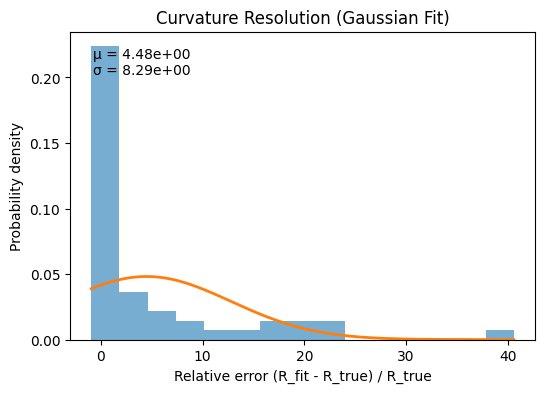

In [36]:
# ---Curvature Resolution---

errs = df_res["rel_err"].values

# Fit Gaussian
mu, sigma = norm.fit(errs)

# Plot
plt.figure(figsize=(6,4))
plt.hist(errs, bins=15, density=True, alpha=0.6)
x = np.linspace(errs.min(), errs.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), linewidth=2)

plt.xlabel("Relative error (R_fit - R_true) / R_true")
plt.ylabel("Probability density")
plt.title("Curvature Resolution (Gaussian Fit)")
plt.text(0.05, 0.95, f"μ = {mu:.2e}\nσ = {sigma:.2e}", 
         transform=plt.gca().transAxes, va="top")

plt.show()


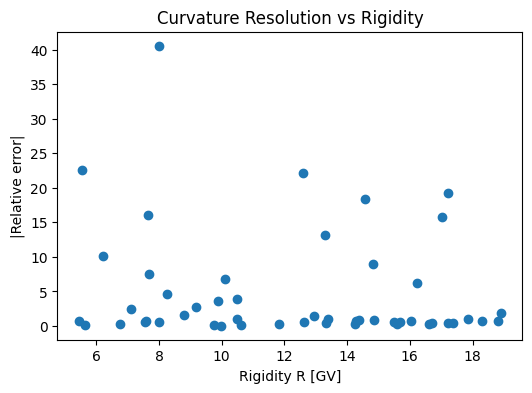

In [37]:
# ---Resolution vs Rigidity---

plt.figure(figsize=(6,4))
plt.scatter(df_res["R_GV"], np.abs(df_res["rel_err"]))
plt.xlabel("Rigidity R [GV]")
plt.ylabel("|Relative error|")
plt.title("Curvature Resolution vs Rigidity")
plt.show()

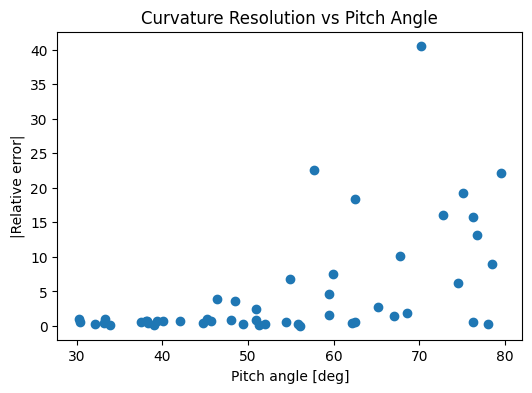

In [38]:
# ---Resolution vs Pitch Angle---

plt.figure(figsize=(6,4))
plt.scatter(df_res["pitch_deg"], np.abs(df_res["rel_err"]))
plt.xlabel("Pitch angle [deg]")
plt.ylabel("|Relative error|")
plt.title("Curvature Resolution vs Pitch Angle")
plt.show()

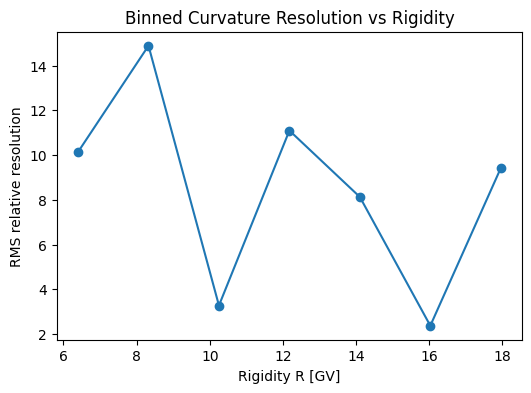

In [39]:
# ---Binned Resolution vs Rigidity---

bins = np.linspace(df_res["R_GV"].min(), df_res["R_GV"].max(), 8)
centers = 0.5 * (bins[1:] + bins[:-1])

rms_vals = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (df_res["R_GV"] >= lo) & (df_res["R_GV"] < hi)
    rms = np.sqrt(np.mean(df_res.loc[mask, "rel_err"]**2))
    rms_vals.append(rms)

plt.figure(figsize=(6,4))
plt.plot(centers, rms_vals, marker="o")
plt.xlabel("Rigidity R [GV]")
plt.ylabel("RMS relative resolution")
plt.title("Binned Curvature Resolution vs Rigidity")
plt.show()

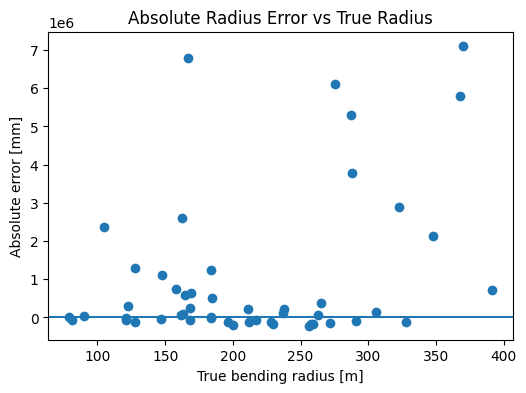

In [40]:
# ---Residuals vs True Radius---

plt.figure(figsize=(6,4))
plt.scatter(df_res["R_theory"], df_res["abs_err_mm"])
plt.axhline(0)
plt.xlabel("True bending radius [m]")
plt.ylabel("Absolute error [mm]")
plt.title("Absolute Radius Error vs True Radius")
plt.show()

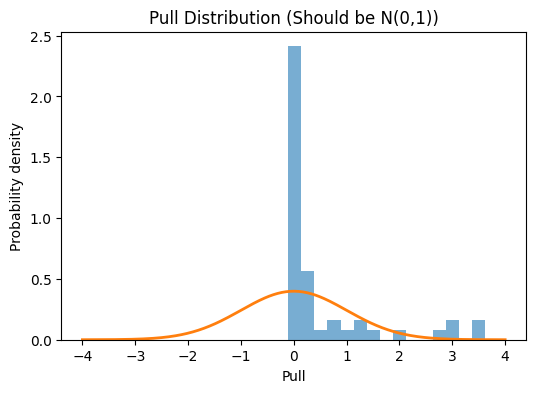

In [41]:
# --Pull Distribution---

sigma_global = df_res["abs_err"].std()

df_res["pull"] = df_res["abs_err"] / sigma_global

plt.figure(figsize=(6,4))
plt.hist(df_res["pull"], bins=15, density=True, alpha=0.6)

x = np.linspace(-4, 4, 300)
plt.plot(x, norm.pdf(x, 0, 1), lw=2)

plt.xlabel("Pull")
plt.ylabel("Probability density")
plt.title("Pull Distribution (Should be N(0,1))")
plt.show()